# nb03_cpx_baseline_models (v10 Phase D)

Loads and visualizes Phase D cpx training results. 96 Optuna studies (same 8x2x2x3 shape as Phase C), zero failures.


In [1]:
import os, sys
from pathlib import Path
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from config import RESULTS
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)


## Base model results (96 rows)


In [2]:
df_bases = pd.read_csv(RESULTS / 'v10_cpx_per_cell_results.csv')
print(f'n_rows={len(df_bases)}')
df_bases.round(3)


n_rows=96


,model,target,track,feature_set,test_rmse,test_r2,cv_rmse
0,RF,T_C,cpx_only,raw,144.435,0.490,145.330
1,ERT,T_C,cpx_only,raw,143.056,0.499,134.373
2,XGB,T_C,cpx_only,raw,145.687,0.481,142.864
3,GB,T_C,cpx_only,raw,146.362,0.476,141.616
4,CatBoost,T_C,cpx_only,raw,139.722,0.522,136.937
...,...,...,...,...,...,...,...
91,GB,P_kbar,cpx_liq,pwlr,7.052,0.726,8.238
92,CatBoost,P_kbar,cpx_liq,pwlr,7.350,0.702,7.990
93,LightGBM,P_kbar,cpx_liq,pwlr,6.537,0.764,8.231
94,ElasticNet,P_kbar,cpx_liq,pwlr,7.776,0.666,9.108


## Ensemble results (36 rows)


In [3]:
df_ens = pd.read_csv(RESULTS / 'v10_cpx_ensemble_results.csv')
df_ens.round(3)


,method,target,track,feature_set,test_rmse
0,ridge,T_C,cpx_only,raw,141.553
1,two_level,T_C,cpx_only,raw,141.677
2,greedy,T_C,cpx_only,raw,142.274
3,ridge,T_C,cpx_only,alr,136.729
4,two_level,T_C,cpx_only,alr,138.969
5,greedy,T_C,cpx_only,alr,136.040
6,ridge,T_C,cpx_only,pwlr,135.886
7,two_level,T_C,cpx_only,pwlr,128.882
8,greedy,T_C,cpx_only,pwlr,129.863
9,ridge,T_C,cpx_liq,raw,74.601


## Best base per (target, track)


In [4]:
idx = df_bases.groupby(['target', 'track'])['test_rmse'].idxmin()
best_per_cell = df_bases.loc[idx].reset_index(drop=True)
best_per_cell[['target','track','model','feature_set','test_rmse','test_r2']].round(3)


,target,track,model,feature_set,test_rmse,test_r2
0,P_kbar,cpx_liq,LightGBM,pwlr,6.537,0.764
1,P_kbar,cpx_only,MLP,alr,13.466,0.544
2,T_C,cpx_liq,CatBoost,pwlr,71.571,0.833
3,T_C,cpx_only,ERT,pwlr,127.350,0.603


## Best ensemble per (target, track)


In [5]:
idx = df_ens.groupby(['target', 'track'])['test_rmse'].idxmin()
best_ens = df_ens.loc[idx].reset_index(drop=True)
best_ens.round(3)


,method,target,track,feature_set,test_rmse
0,ridge,P_kbar,cpx_liq,pwlr,6.522
1,two_level,P_kbar,cpx_only,raw,14.285
2,ridge,T_C,cpx_liq,pwlr,68.360
3,two_level,T_C,cpx_only,pwlr,128.882


## Figure: per-model test RMSE heatmap


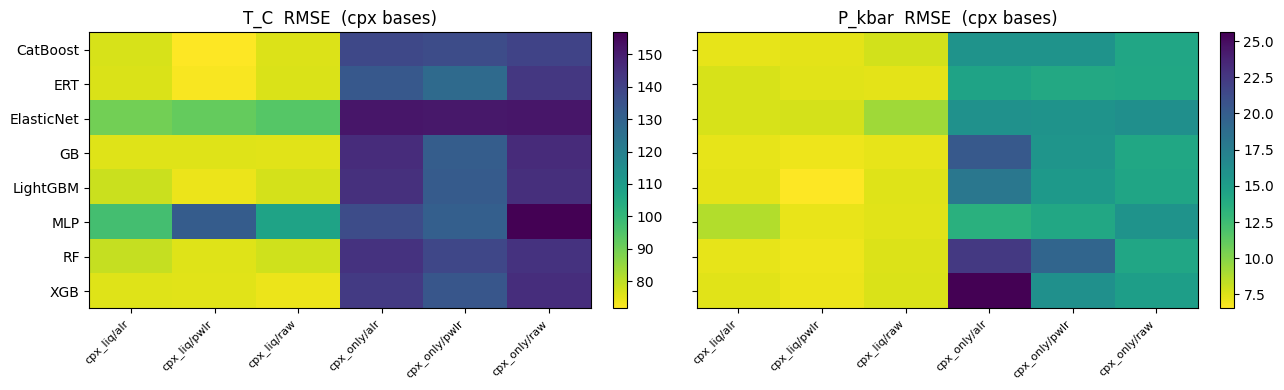

In [6]:
pv = df_bases.pivot_table(index='model',
                          columns=['target','track','feature_set'],
                          values='test_rmse')
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, tgt in zip(axes, ['T_C', 'P_kbar']):
    sub = pv[tgt]
    im = ax.imshow(sub.values, aspect='auto', cmap='viridis_r')
    ax.set_xticks(range(sub.shape[1]))
    ax.set_xticklabels([f'{t}/{f}' for t, f in sub.columns],
                       rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(sub.shape[0]))
    ax.set_yticklabels(sub.index)
    ax.set_title(f'{tgt}  RMSE  (cpx bases)')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


## Figure: base vs ensemble RMSE per cell


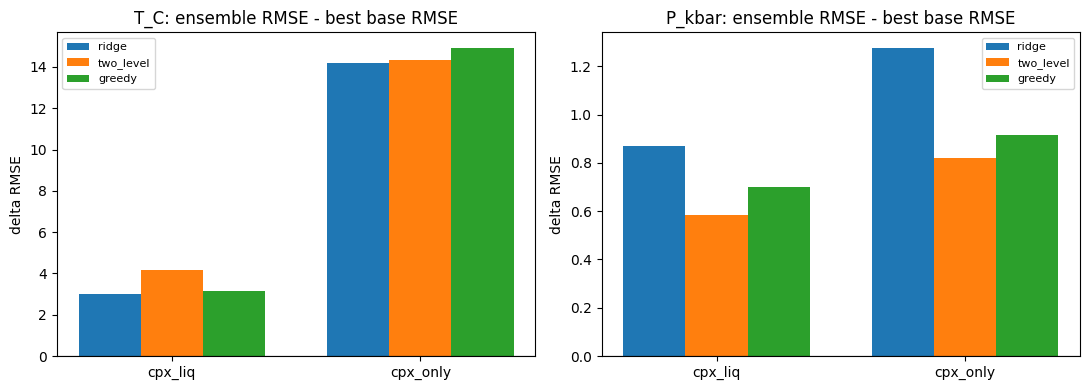

In [7]:
best_base = df_bases.loc[df_bases.groupby(['target','track'])['test_rmse']
                                  .idxmin(), ['target','track','test_rmse']]
best_base = best_base.rename(columns={'test_rmse': 'best_base_rmse'})
merged = df_ens.merge(best_base, on=['target', 'track'])
merged['delta'] = merged['test_rmse'] - merged['best_base_rmse']

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, tgt in zip(axes, ['T_C', 'P_kbar']):
    sub = merged[merged['target'] == tgt]
    methods = sub['method'].unique()
    tracks  = sorted(sub['track'].unique())
    x = np.arange(len(tracks))
    w = 0.25
    for i, m in enumerate(methods):
        vals = [sub[(sub['method']==m) & (sub['track']==t)]['delta'].values[0]
                for t in tracks]
        ax.bar(x + i*w - w, vals, w, label=m)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(tracks)
    ax.set_title(f'{tgt}: ensemble RMSE - best base RMSE')
    ax.set_ylabel('delta RMSE'); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Test protocol results


In [8]:
from scripts.v10_test_protocol import summarize_tests
tests_df = summarize_tests(pipeline='cpx')
print(f'n_test_rows={len(tests_df)}')
tests_df[['test_id','target','track','passed','value','threshold']].head(60)


n_test_rows=48


,test_id,target,track,passed,value,threshold
0,T01,P_kbar,cpx_liq,True,0.050434,NaN
1,T01,P_kbar,cpx_liq,True,0.038519,NaN
2,T01,P_kbar,cpx_liq,True,0.478206,NaN
3,T01,P_kbar,cpx_only,True,0.048679,NaN
4,T01,P_kbar,cpx_only,False,-1.238597,NaN
5,T01,P_kbar,cpx_only,False,-1.233986,NaN
6,T01,T_C,cpx_liq,True,2.117825,NaN
7,T01,T_C,cpx_liq,True,0.853078,NaN
8,T01,T_C,cpx_liq,True,0.932833,NaN
9,T01,T_C,cpx_only,True,3.333689,NaN


In [9]:
if not tests_df.empty:
    rate = tests_df.groupby('test_id')['passed'].agg(['sum', 'count'])
    rate['pass_rate'] = rate['sum'] / rate['count']
    print(rate)


         sum  count  pass_rate
test_id                       
T01        8     12   0.666667
T02        5     12   0.416667
T11       10     12   0.833333
T12        1     12   0.083333


## Summary

Phase D cpx training complete. Canonical models under `models/canonical/cpx/`.
